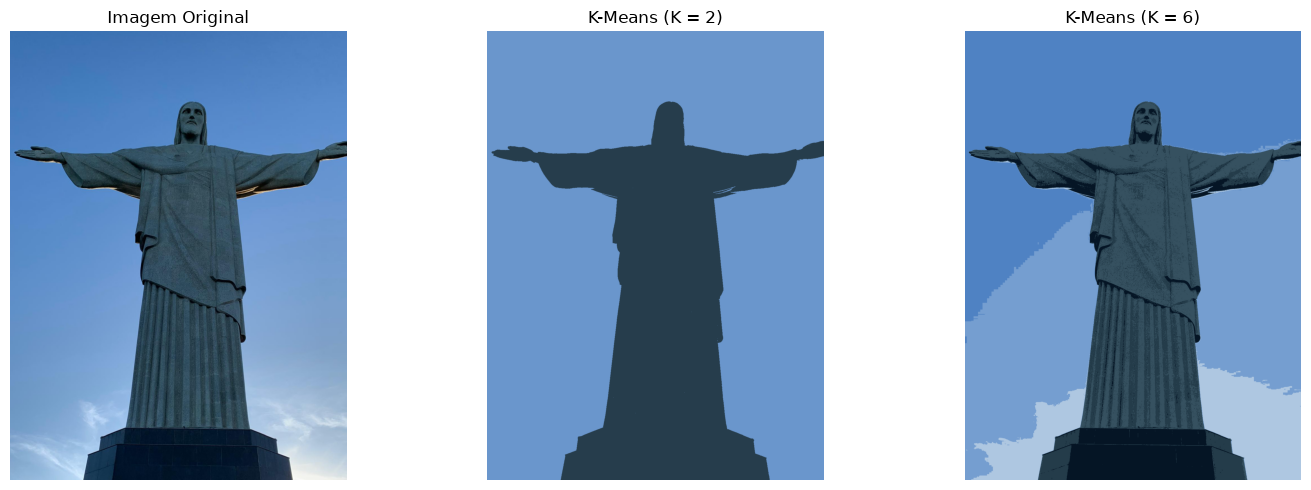

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segmentar_kmeans(imagem_path, k):
    # Carregar a imagem
    imagem = cv2.imread(imagem_path)
    
    # Converter de BGR (padrão OpenCV) para RGB (padrão Matplotlib)
    imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
    
    # Reformatar os pixels para uma matriz 2D (N_pixels, 3 canais de cor)
    pixel_values = imagem_rgb.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    
    # Definir critérios de parada do K-Means (100 iterações ou precisão de 0.2)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    
    # Aplicar o algoritmo K-Means
    _, labels, centers = cv2.kmeans(
        pixel_values, 
        k, 
        None, 
        criteria, 
        10, 
        cv2.KMEANS_RANDOM_CENTERS
    )
    
    # Converter os centros dos clusters para inteiros de 8 bits (0-255)
    centers = np.uint8(centers)
    
    # Mapear cada pixel para a cor do centro do seu cluster
    segmented_data = centers[labels.flatten()]
    
    # Remodular a matriz para o formato/dimensões originais da imagem
    segmented_image = segmented_data.reshape((imagem_rgb.shape))
    
    return imagem_rgb, segmented_image

# --- EXECUÇÃO E PLOTAGEM ---

# Caminho completo da sua imagem
caminho_imagem = r"Cristo_Redentor.jpg"

# Processar para K = 2 e K = 6
imagem_original, img_k2 = segmentar_kmeans(caminho_imagem, k=2)
_, img_k6 = segmentar_kmeans(caminho_imagem, k=6)

# Exibir os resultados lado a lado
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagem_original)
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_k2)
plt.title('K-Means (K = 2)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_k6)
plt.title('K-Means (K = 6)')
plt.axis('off')

plt.tight_layout()
plt.show()